<a href="https://colab.research.google.com/github/luizby20/Practica-2/blob/main/Cinem%C3%A1tica_inversa_IK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -nc 'https://raw.githubusercontent.com/Jegovila/SI2/refs/heads/main/14%20Cinem%C3%A1tica%20Inversa/Dibujar_Manipulador.py'

import numpy as np
import matplotlib.pyplot as plt
from Dibujar_Manipulador import dibujar_manipulador
from IPython import display

--2026-04-27 21:00:37--  https://raw.githubusercontent.com/Jegovila/SI2/refs/heads/main/14%20Cinem%C3%A1tica%20Inversa/Dibujar_Manipulador.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1067 (1.0K) [text/plain]
Saving to: ‘Dibujar_Manipulador.py’

Dibujar_Manipulador 100%[===================>]   1.04K  --.-KB/s    in 0s      

2026-04-27 21:00:38 (47.3 MB/s) - ‘Dibujar_Manipulador.py’ saved [1067/1067]



Función de penalización

In [2]:
def Penalty(x, xl, xu):
    D = x.size
    z = 0
    # Aqui agrega tu función de penalización
    for j in range(D):
        # Si la articulación supera sus límites (inferior o superior), se penaliza
        if x[j] < xl[j] or x[j] > xu[j]:
            z += 1
    #----------------------------------
    return z

Función objetivo

In [3]:
f = lambda q: 0.5 * np.sum((np.array(pd) - p(q[0], q[1], q[2]))**2)
# fp suma el error cuadrático más la penalización multiplicada por beta
fp = lambda x, xl, xu: f(x) + beta * Penalty(x, xl, xu)

Parámetros

In [4]:
animacion = 1
pd = [0.4, 0.4]
a_1 = 0.35
a_2 = 0.35
a_3 = 0.25

beta = 1000
# Límites inferior y superior para los ángulos (en radianes)
xl = np.array([-np.pi, -np.pi, -np.pi])
xu = np.array([np.pi, np.pi, np.pi])

G = 150    # Generaciones (Iteraciones)
N = 50     # Tamaño de la población (Individuos)
D = 3      # Dimensión (3 articulaciones)

F = 0.6    # Factor de Mutación
CR = 0.9   # Tasa de Recombinación

# DE

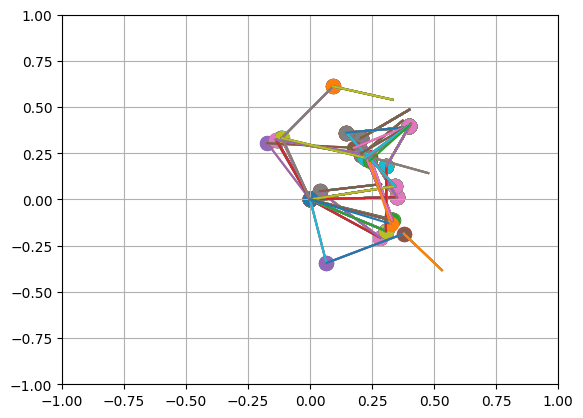

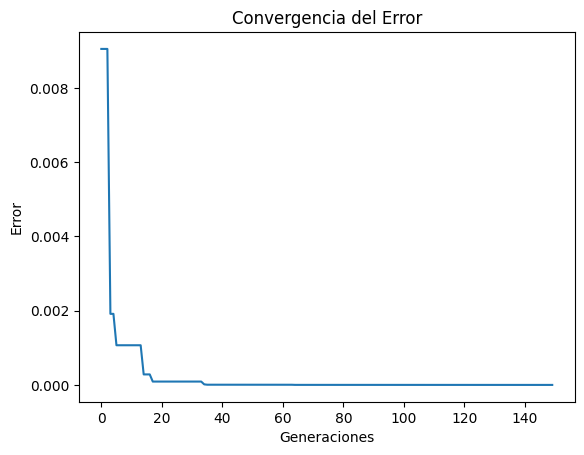

In [5]:
p = lambda theta_1, theta_2, theta_3: np.array([a_2*np.cos(theta_1 + theta_2) + a_1*np.cos(theta_1) + a_3*np.cos(theta_1 + theta_2 + theta_3),
                                                a_2*np.sin(theta_1 + theta_2) + a_1*np.sin(theta_1) + a_3*np.sin(theta_1 + theta_2 + theta_3)])

x = np.zeros((D, N))
fitness = np.zeros(N)

# Inicialización
for i in range(N):
    x[:, i] = xl + (xu - xl) * np.random.rand(D)
    # NOTA: Cambiamos f() por fp() para que considere la penalización desde el inicio
    fitness[i] = fp(x[:, i], xl, xu)

fx_plot = np.zeros(G)

for n in range(G):
    if animacion:
        # Se dibuja un individuo de la población para ver cómo avanza
        for i in range(0, N, 50):
          display.display(plt.gcf())
          display.clear_output(wait=True)
          plt.scatter(pd[0], pd[1], marker='o', s=100)
          dibujar_manipulador(x[:, i])

    for i in range(N):
        # --- Mutación ---
        # Se eligen 3 vectores aleatorios distintos al actual
        idxs = [idx for idx in range(N) if idx != i]
        r1, r2, r3 = np.random.choice(idxs, 3, replace=False)
        v = x[:, r1] + F * (x[:, r2] - x[:, r3])

        # --- Recombinación ---
        u = np.zeros(D)
        j_rand = np.random.randint(D)
        for j in range(D):
            if np.random.rand() <= CR or j == j_rand:
                u[j] = v[j]
            else:
                u[j] = x[j, i]

        # --- Selección ---
        # Evaluar la aptitud del nuevo vector usando fp (con penalización)
        fitness_u = fp(u, xl, xu)

        if fitness_u < fitness[i]:
            x[:, i] = u.copy()
            fitness[i] = fitness_u

    fx_plot[n] = np.min(fitness)

# Obtener al mejor individuo de toda la optimización
igb = np.argmin(fitness)
q = x[:, igb]

theta_1 = q[0]
theta_2 = q[1]
theta_3 = q[2]

# Posición alcanzada
p_final = p(theta_1, theta_2, theta_3)

# Dibujar resultado final
display.display(plt.gcf())
display.clear_output(wait=True)
dibujar_manipulador(q)

plt.show()

# Graficar la convergencia del error
plt.plot(fx_plot)
plt.title("Convergencia del Error")
plt.xlabel("Generaciones")
plt.ylabel("Error")
plt.show()